In [3]:
import networkx as nx
import matplotlib.pyplot as plt

#### Get the generated workflow in its intermediate shape

In [86]:
import os
import json
f = open("/home/markus/src/bpmn-assistant/src/bpmn_assistant/jsont.txt", "r")
raw = f.read()
f.close()
raw = raw[raw.rfind('```json\n') + 8:raw.rfind('```\n')]
flow = json.loads(raw)
flow

{'elements': [{'id': 'start',
   'type': 'startEvent',
   'label': None,
   'variables': None,
   'incoming': [],
   'outgoing': ['start-submitRequest']},
  {'id': 'submitRequest',
   'type': 'userTask',
   'label': 'Submit request',
   'variables': [{'id': 'justification', 'readOnly': 'no', 'type': 'String'},
    {'id': 'targetDate', 'readOnly': 'no', 'type': 'Date'}],
   'incoming': ['start-submitRequest'],
   'outgoing': ['submitRequest-approverReview']},
  {'id': 'approverReview',
   'type': 'userTask',
   'label': 'Review & comment',
   'variables': [{'id': 'approvalComment', 'readOnly': 'no', 'type': 'String'},
    {'id': 'decision', 'readOnly': 'no', 'type': 'String'}],
   'incoming': ['submitRequest-approverReview'],
   'outgoing': ['approverReview-decisionGateway']},
  {'id': 'decisionGateway',
   'type': 'exclusiveGateway',
   'label': 'Approved?',
   'variables': None,
   'incoming': ['approverReview-decisionGateway'],
   'outgoing': ['decisionGateway-fulfillRequest',
    'd

### Build a networkx graph structure

In [87]:
#
# elements wind up as graph nodes, flows as edges
#  
DG = nx.DiGraph()
node_to_index = {}
#G.add_node('Z')

# add nodes
for i, node in enumerate(flow['elements']):
    DG.add_node(node['id'], **node)
    node_to_index[node['id']] = i


# add edges via nodes
#   flow labels encode start and end node labels as '<start>-<end>'
#   so we don't use sourceRef, targetRef and use split('-') instead
for i, node in enumerate(flow['elements']):
    if len(node['incoming']) > 0:
        for incoming in node['incoming']:
            DG.add_edge(incoming.split('-')[0], node['id'])
    if len(node['outgoing']) > 0:
        for gw, outgoing in enumerate(node['outgoing']):
            gateway = {'gateway' : gw > 0}
            print('Here', outgoing, outgoing, node_to_index[outgoing.split('-')[1]], gateway)
            DG.add_edge(node['id'], outgoing.split('-')[1], **gateway)

Here start-submitRequest start-submitRequest 1 {'gateway': False}
Here submitRequest-approverReview submitRequest-approverReview 2 {'gateway': False}
Here approverReview-decisionGateway approverReview-decisionGateway 3 {'gateway': False}
Here decisionGateway-fulfillRequest decisionGateway-fulfillRequest 4 {'gateway': False}
Here decisionGateway-endReject decisionGateway-endReject 6 {'gateway': True}
Here fulfillRequest-endSuccess fulfillRequest-endSuccess 5 {'gateway': False}


In [88]:
# naive plot
#fig, ax = plt.subplots(1,1, figsize=(4,3))
#nx.draw(DG, font_size=8, ax=ax)

### Proper Layout

In [89]:
for i,node in enumerate(DG.nodes):
    if 'pos' in DG.nodes[node]:
        del DG.nodes[node]['pos']

pos = {}
labels = {}
labelpos = {}
# position startEvent
unlabeled = True
depth = 1

while unlabeled:
    for i,node in enumerate(DG.nodes):
        unlabeled = False
        # if node is unlabeled look for a suitable position
        # use incoming to determine the row
        # if incoming is empty use the current position (startEvent)
        if 'pos' in DG.nodes[node]:   # labeled node
            continue
            
        unlabeled = True  
        if len(DG.nodes[node]['incoming']) == 0:
            pos[node] = (0,1)
            DG.nodes[node]['pos'] = (0,1)
            labels[node] = node
            labelpos[node] = (0,1)
        else:
            prevNode = DG.nodes[node]['incoming'][0].split('-')[0]
            #print(prevNode)
            prevPos = DG.nodes[prevNode]['pos'] # find free position looking right
            #print(prevPos[0])
            # handle gateways, when this node is the 2nd outgoing
            print(prevNode, DG.nodes[prevNode]['outgoing'])
            if len(DG.nodes[prevNode]['outgoing']) > 1 and DG.nodes[prevNode]['outgoing'][1].split('-')[1] == node:
                prevPos = (prevPos[0]+1, prevPos[1]-1)
                depth -= 1
            else:
                prevPos = (prevPos[0]+1, prevPos[1])
            pos[node] = prevPos
            DG.nodes[node]['pos'] = prevPos
            labels[node] = node
            labelpos[node] = (prevPos[0], prevPos[1])

# fix plotting stuff
for i, node in enumerate(labelpos):
    print('Depth', depth, node, labelpos[node])
    if labelpos[node][1] == depth:
        print("asdfadsf")
        labelpos[node] = (labelpos[node][0], labelpos[node][1] + 0.15)
    else:
        labelpos[node] = (labelpos[node][0], labelpos[node][1] - 0.15)
        

start ['start-submitRequest']
submitRequest ['submitRequest-approverReview']
approverReview ['approverReview-decisionGateway']
decisionGateway ['decisionGateway-fulfillRequest', 'decisionGateway-endReject']
fulfillRequest ['fulfillRequest-endSuccess']
decisionGateway ['decisionGateway-fulfillRequest', 'decisionGateway-endReject']
Depth 0 start (0, 1)
Depth 0 submitRequest (1, 1)
Depth 0 approverReview (2, 1)
Depth 0 decisionGateway (3, 1)
Depth 0 fulfillRequest (4, 1)
Depth 0 endSuccess (5, 1)
Depth 0 endReject (4, 0)
asdfadsf


Text(0.5, 1.0, 'Manual manhattan style workflow layout')

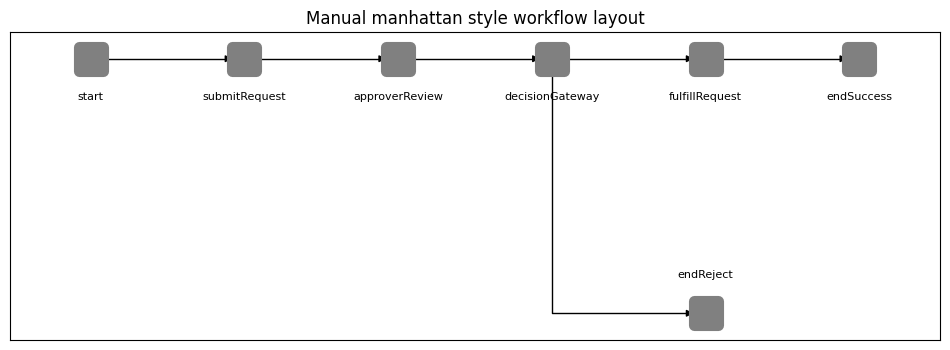

In [90]:
fig, ax = plt.subplots(1,1, figsize=(12, 4))
#fig.subplots_adjust(top=0.35)
nx.draw_networkx_nodes(DG, pos, node_shape='s', ax=ax, node_color='grey', linewidths=8)
nx.draw_networkx_labels(DG, labelpos, labels=labels, font_size=8)
nx.draw_networkx_edges(
    DG, pos, connectionstyle="angle,rad=0.0",  # <-- THIS IS IT
    ax=ax
)
ax.set_title("Manual manhattan style workflow layout")

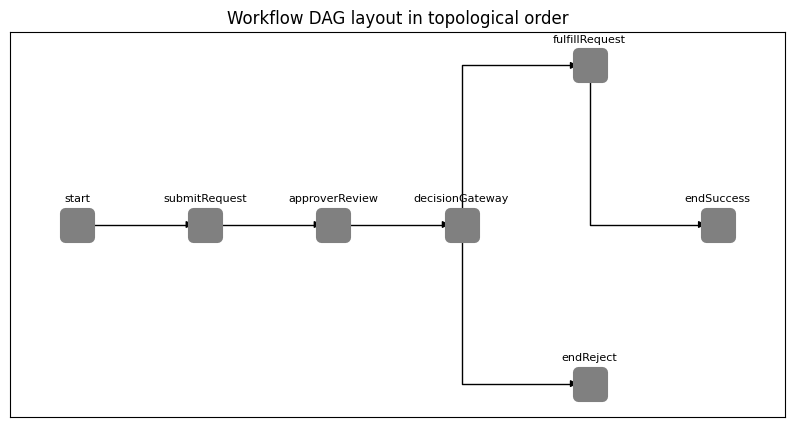

In [91]:
for layer, nodes in enumerate(nx.topological_generations(DG)):
    # `multipartite_layout` expects the layer as a node attribute, so add the
    # numeric layer value as a node attribute
    for node in nodes:
        DG.nodes[node]["layer"] = layer
# Compute the multipartite_layout using the "layer" node attribute
pos2 = nx.multipartite_layout(DG, subset_key="layer")
labelpos2 = {}
for p in pos2:
    labelpos2[p] = (pos2[p][0], pos2[p][1]+0.03)

fig, ax = plt.subplots(1,1,figsize=(10,5))
nx.draw_networkx_nodes(DG, pos2, node_shape='s', ax=ax, node_color='grey', linewidths=8)
nx.draw_networkx_labels(DG, labelpos2, labels=labels, font_size=8)
nx.draw_networkx_edges(
    DG, pos2, connectionstyle="angle,rad=0.0",  # <-- THIS IS IT
    ax=ax
)


#nx.draw_networkx(DG, pos=pos, ax=ax, node_shape='s', node_color='grey', linewidths=8, connectionstyle="angle,rad=0.0", font_size=8)
ax.set_title("Workflow DAG layout in topological order")
#fig.tight_layout()
plt.show()

In [92]:
DG.edges

OutEdgeView([('start', 'submitRequest'), ('submitRequest', 'approverReview'), ('approverReview', 'decisionGateway'), ('decisionGateway', 'fulfillRequest'), ('decisionGateway', 'endReject'), ('fulfillRequest', 'endSuccess')])

### Add cycle - reject => go back to start

In [93]:
DG.add_edge('endReject', 'submitRequest')
#DG.add_edge('endSuccess', 'approverReview')

In [94]:
nx.find_cycle(DG)[3]

('endReject', 'submitRequest')

In [95]:
removed_edges = []

# should be a loop !while
while not nx.is_directed_acyclic_graph(DG):
    # remove edges in cycles with nodes in wrong order (go back edges)
    cycle = nx.find_cycle(DG)
    node_list = list(DG.nodes)
    for e in cycle:
        if node_list.index(e[0]) > node_list.index(e[1]):
            print('REMOVE', e)
            removed_edges.append(e)
            DG.remove_edge(e[0], e[1])
            break

print(nx.is_directed_acyclic_graph(DG), removed_edges[0])


for layer, nodes in enumerate(nx.topological_generations(DG)):
    # `multipartite_layout` expects the layer as a node attribute, so add the
    # numeric layer value as a node attribute
    for node in nodes:
        DG.nodes[node]["layer"] = layer
        print('layer', layer)

# Compute the multipartite_layout using the "layer" node attribute
pos2 = nx.multipartite_layout(DG, subset_key="layer")
acyclic = list(DG.edges)

# add edge causing a cycle back - should be a loop !
for e in removed_edges:
    DG.add_edge(e[0], e[1])

REMOVE ('endReject', 'submitRequest')
True ('endReject', 'submitRequest')
layer 0
layer 1
layer 2
layer 3
layer 4
layer 4
layer 5


In [96]:
DG.edges

OutEdgeView([('start', 'submitRequest'), ('submitRequest', 'approverReview'), ('approverReview', 'decisionGateway'), ('decisionGateway', 'fulfillRequest'), ('decisionGateway', 'endReject'), ('fulfillRequest', 'endSuccess'), ('endReject', 'submitRequest')])

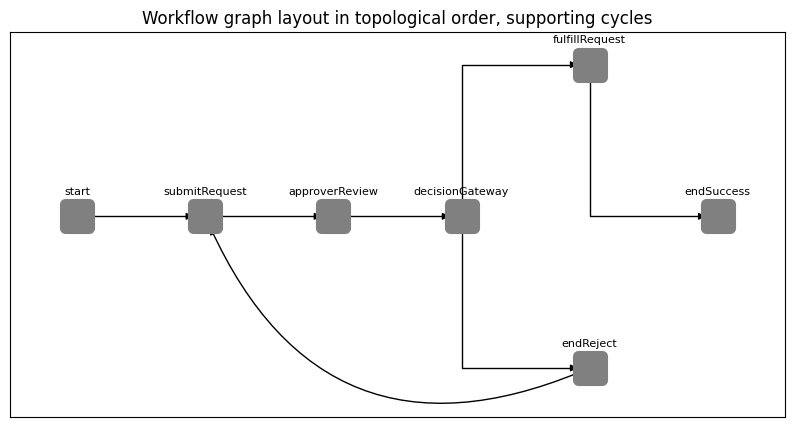

In [97]:
    
labelpos2 = {}
for p in pos2:
    labelpos2[p] = (pos2[p][0], pos2[p][1]+0.03)

fig, ax = plt.subplots(1,1,figsize=(10,5))
nx.draw_networkx_nodes(DG, pos2, node_shape='s', ax=ax, node_color='grey', linewidths=8)
nx.draw_networkx_labels(DG, labelpos2, labels=labels, font_size=8)

nx.draw_networkx_edges(
    DG, pos2, edgelist=acyclic, connectionstyle="angle,rad=0.0",  # <-- THIS IS IT
    ax=ax
)
nx.draw_networkx_edges(
    DG, pos2, edgelist=removed_edges, ax=ax, connectionstyle="arc3, rad=-0.5"
)



#nx.draw_networkx(DG, pos=pos, ax=ax, node_shape='s', node_color='grey', linewidths=8, connectionstyle="angle,rad=0.0", font_size=8)
ax.set_title("Workflow graph layout in topological order, supporting cycles")
#fig.tight_layout()
plt.show()

### To Elyra

In [98]:
elyra_nodes = []
for i,node in enumerate(DG.nodes): 
    DG.nodes[node]['op'] = DG.nodes[node]['type']
    if i == 0:
        DG.nodes[node]['type'] = 'startEvent'
    else:
        DG.nodes[node]['type'] = 'execution_node'
    DG.nodes[node]['app_data'] = {"react_nodes_data" : {"shape": "circle"},
                                  'ui_data':{"label": DG.nodes[node]['id'], 'description': 'Nothing special', "image": "userinput.svg", 
                                 "x_pos": DG.nodes[node]['pos'][0]*100, "y_pos": DG.nodes[node]['pos'][1]*100}}
    inputs = []
    for incoming in DG.nodes[node]['incoming']:
        right = incoming.split('-')[0]
        left = incoming.split('-')[1]
        inputs.append({'id': 'inPort', 'app_data': {'ui_data':{'cardinality' : {'min': 1, 'max': -1}, 'label': 'Input Port'}},
                       'links': [{'id': 'whatever', 'node_id_ref': right, 'port_id_ref': 'outPort'}] })
    DG.nodes[node]['inputs'] = inputs

    outputs = []
    for outgoing in DG.nodes[node]['outgoing']:
        #right = outgoing.split('-')[0]
        left = outgoing.split('-')[1]
        outputs.append({'id': 'outPort', 'app_data': {'ui_data': {'cardinality' : {'min': 1, 'max': -1}, 'label': 'Output Port'}}})
    DG.nodes[node]['outputs'] = outputs


In [99]:
nodes = []
for node in DG.nodes:
    try:
        del DG.nodes[node]['pos']
        del DG.nodes[node]['variables']
        del DG.nodes[node]['incoming']
        del DG.nodes[node]['outgoing']
        del DG.nodes[node]['layer']
        del DG.nodes[node]['label']
    except Exception as e:
        print(e)
    
    nodes.append(DG.nodes[node])


In [100]:
nodes[1]

{'id': 'submitRequest',
 'type': 'execution_node',
 'op': 'userTask',
 'app_data': {'react_nodes_data': {'shape': 'circle'},
  'ui_data': {'label': 'submitRequest',
   'description': 'Nothing special',
   'image': 'userinput.svg',
   'x_pos': 100,
   'y_pos': 100}},
 'inputs': [{'id': 'inPort',
   'app_data': {'ui_data': {'cardinality': {'min': 1, 'max': -1},
     'label': 'Input Port'}},
   'links': [{'id': 'whatever',
     'node_id_ref': 'start',
     'port_id_ref': 'outPort'}]}],
 'outputs': [{'id': 'outPort',
   'app_data': {'ui_data': {'cardinality': {'min': 1, 'max': -1},
     'label': 'Output Port'}}}]}

In [101]:
import json
js = {"doc_type": "pipeline", "version": "3.0","json_schema": "http://api.dataplatform.ibm.com/schemas/common-pipeline/pipeline-flow/pipeline-flow-v3-schema.json",
"id": "95bd66ca-5791-4bc6-bef7-2cb10c566303","primary_pipeline": "184d6105-2151-4d5d-ba99-21ef3282543a",'pipelines' : 
      [{'id': '184d6105-2151-4d5d-ba99-21ef3282543a', 'nodes': nodes,
      "app_data": {
        "ui_data": {
          "comments": []
        }
      },
      "runtime_ref": ""
    }
  ],
  "schemas": []
}

js_str = json.dumps(js)
f = open('generated-flow.json', 'w')
f.write(js_str)
f.close()

### Testing the layout

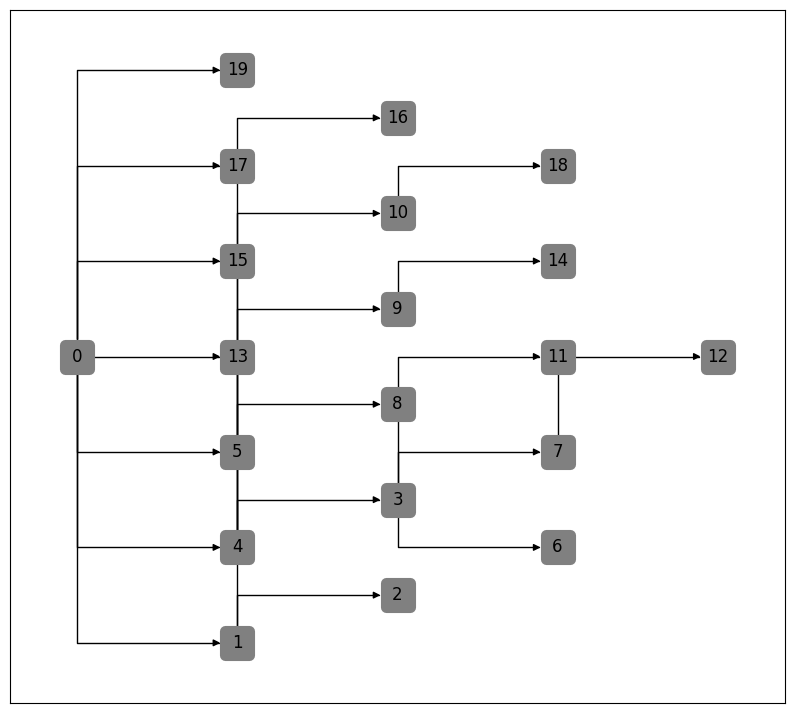

In [68]:
DG2 = nx.gnr_graph(20, 0.3).reverse(copy=True)
for layer, nodes in enumerate(nx.topological_generations(DG2)):
    # `multipartite_layout` expects the layer as a node attribute, so add the
    # numeric layer value as a node attribute
    for node in nodes:
        DG2.nodes[node]["layer"] = layer
# Compute the multipartite_layout using the "layer" node attribute
pos3 = nx.multipartite_layout(DG2, subset_key="layer")

fig, ax = plt.subplots(1,1,figsize=(10,9))
nx.draw_networkx(DG2, pos3, node_shape='s', ax=ax, node_color='grey', linewidths=8, connectionstyle="angle,rad=0.0")
